In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from lightgbm import LGBMClassifier
import warnings
from sklearn.model_selection import KFold, ParameterSampler, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

We use an unconventional naming scheme here: 
- training
- testing
- out-of-time validation set

We leave the validation set out for real out-of-time validation, and for the rest, we apply a k-fold cv.

We unfortunately only have a full year of data. Ideally, we would want to have at least one year of data in the training + testing partition to have the model to learn through seasonality. 

However, given the circumstance, we would have to compromise on this and leave some of the months for real out-of-time validation set for true out-of-sample validation.

### Data Prep

In [2]:
df = pd.read_parquet('data/candidate_variables.parquet')
df.Date.min(), df.Date.max()

(Timestamp('2010-01-15 00:00:00'), Timestamp('2010-12-31 00:00:00'))

In [3]:
df_oot = df[df.Date >= '2010-11-01']
df_train_test = df[df.Date < '2010-11-01']

In [4]:
selected_features = pd.read_csv('data/selected_features_ks.csv')
TOP_NVAR = 18
selected_features = selected_features['feature'].tolist()[:TOP_NVAR]

In [5]:
selected_features

['Cardnum_unique_count_for_card_state_1',
 'card_merchdesc_state_total_14',
 'card_dow_count_1_by_30',
 'merchnum_desc_total_1',
 'card_zip3_total_30',
 'card_merchdesc_zip_max_60',
 'card_dow_unique_count_for_Merchnum_1',
 'card_merchdesc_zip_actual/med_60',
 'card_merchnum_state_total_amount_1_by_60',
 'card_dow_count_0_by_30_sq',
 'card_dow_count_0_by_30',
 'card_dow_count_1_by_30_sq',
 'card_dow_vdratio_0by30',
 'card_dow_vdratio_1by30',
 'Cardnum_vdratio_1by7',
 'card_dow_unique_count_for_merch_state_1',
 'card_dow_unique_count_for_card_merchnum_state_3',
 'card_dow_unique_count_for_card_merch_3']

The model building pipeline is delineated as follows:

1. Robust Scaler
2. Clip outliers
3. Standard Scaler
4. PCA (Optional)
5. Model building

### Exploratory Analysis for PCA

Before we do that, though, we should implement exploratory analysis and visualize variance as a function of number of components.

In [6]:
X_train_test = df_train_test[selected_features]
y_train_test = df_train_test['Fraud']
X_oot = df_oot[selected_features]
y_oot = df_oot['Fraud']

In [7]:
CLIP_THRESHOLD = 10

robust_scaler = RobustScaler()
X_robust = robust_scaler.fit_transform(X_train_test)

X_clipped = np.clip(X_robust, -CLIP_THRESHOLD, CLIP_THRESHOLD)

standard_scaler = StandardScaler()
X_scaled = standard_scaler.fit_transform(X_clipped)

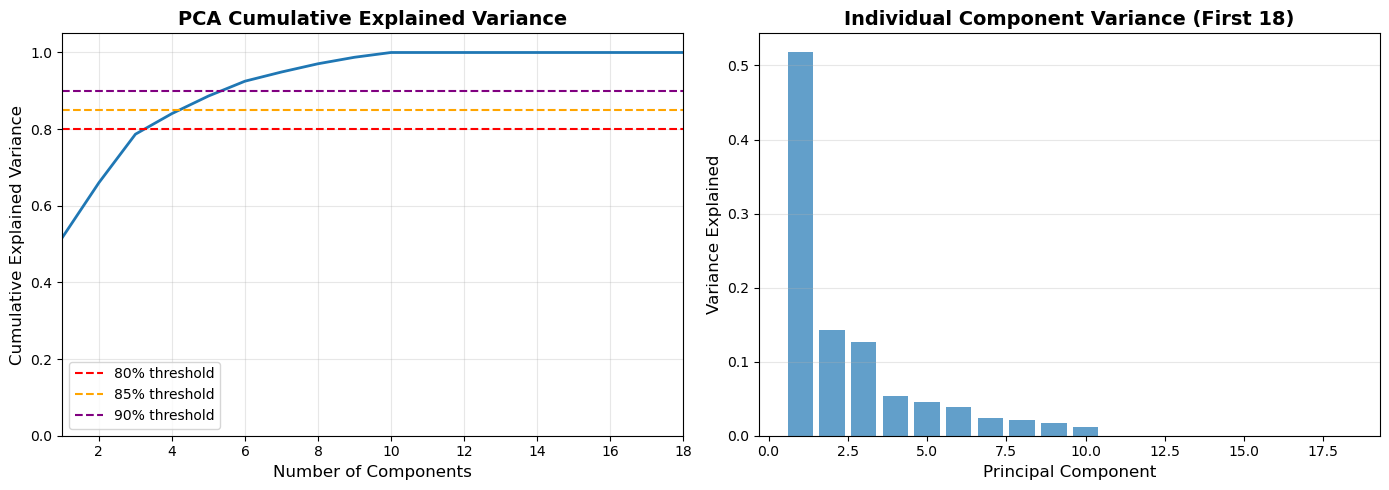

In [8]:
pca_full = PCA()
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
ax1.plot(range(1, len(cumsum_var) + 1), cumsum_var, linewidth=2)
ax1.axhline(y=0.80, color='r', linestyle='--', label='80% threshold', linewidth=1.5)
ax1.axhline(y=0.85, color='orange', linestyle='--', label='85% threshold', linewidth=1.5)
ax1.axhline(y=0.90, color='purple', linestyle='--', label='90% threshold', linewidth=1.5)
ax1.set_xlabel('Number of Components', fontsize=12)
ax1.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax1.set_title('PCA Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_xlim(1, len(cumsum_var))
ax1.set_ylim(0, 1.05)

ax2 = axes[1]
n_bars = min(18, len(pca_full.explained_variance_ratio_))
ax2.bar(range(1, n_bars + 1), pca_full.explained_variance_ratio_[:n_bars], alpha=0.7)
ax2.set_xlabel('Principal Component', fontsize=12)
ax2.set_ylabel('Variance Explained', fontsize=12)
ax2.set_title(f'Individual Component Variance (First {n_bars})', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Model Building

#### Fraud Detection Rate

Let $N$ be the total number of transactions.

Let $y_i \in \{0, 1\}$ be the true label for transaction $i$, where $1$ is fraud and $0$ is not fraud.

Let $r$ be the detection rate (e.g., $r = 0.03$ for 3%).

Let $k = \lceil N \times r \rceil$ be the number of transactions we are investigating (the top 3%).

Let $S_k$ be the set of indices of the $k$ transactions with the *highest predicted probabilities* of fraud.

The Fraud Detection Rate at rate $r$ is calculated as the number of actual frauds within our top $k$ predictions divided by the total number of actual frauds in the entire dataset:

$$\text{FDR@}r = \frac{\sum_{i \in S_k} y_i}{\sum_{i=1}^{N} y_i}$$

In [9]:
def calculate_fdr_at_rate(y_true, y_pred_proba, detect_rate=0.03):
    n_top = int(round(len(y_true) * detect_rate))
    top_indices = np.argpartition(y_pred_proba, -n_top)[-n_top:]
    return y_true.iloc[top_indices].sum() / y_true.sum()


def evaluate_model_cv(
    X_train_test,
    y_train_test,
    X_oot,
    y_oot,
    model,
    n_splits=5,
    detect_rate=0.03,
    use_pca=False,
    n_components=None,
    use_standard_scaler=True,
    handle_imbalance=None,
    jitter_scale=0.1,
    jitter_reps=2,
):
    """Cross-validated FDR evaluation.

    handle_imbalance : {None, "smote", "jitter", "downsample"}
        - None: no imbalance handling
        - "smote": apply SMOTE via imblearn Pipeline
        - "jitter": oversample minority class by adding noise to its features
        - "downsample": undersample non-fraud to get ~1:1 fraud:non-fraud
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=69)
    results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_test)):
        X_train, X_val = X_train_test.iloc[train_idx], X_train_test.iloc[val_idx]
        y_train, y_val = y_train_test.iloc[train_idx], y_train_test.iloc[val_idx]

        steps = [
            ("robust", RobustScaler()),
            ("clip", FunctionTransformer(func=np.clip, kw_args={"a_min": -10, "a_max": 10})),
        ]
        if use_standard_scaler:
            steps.append(("standard", StandardScaler()))
        if use_pca:
            steps.append(("pca", PCA(n_components=n_components)))
        if handle_imbalance == "smote":
            steps.append(("smote", SMOTE(random_state=69)))

        steps.append(("model", clone(model)))

        if handle_imbalance == "smote":
            pipeline = ImbPipeline(steps)
        else:
            pipeline = Pipeline(steps)

        # Prepare training data (optionally with jitter or downsampling)
        X_train_fit, y_train_fit = X_train, y_train

        if handle_imbalance == "jitter":
            X_trn_bads = X_train[y_train == 1]
            y_trn_bads = y_train[y_train == 1]

            if len(X_trn_bads) > 0:
                X_train_fit = X_train.copy()
                y_train_fit = y_train.copy()

                for _ in range(jitter_reps):
                    noise = 1 + jitter_scale * np.random.uniform(-1, 1, size=X_trn_bads.shape)
                    X_trn_more = X_trn_bads * noise
                    X_train_fit = pd.concat([X_train_fit, X_trn_more], axis=0)
                    y_train_fit = pd.concat([y_train_fit, y_trn_bads], axis=0)

        elif handle_imbalance == "downsample":
            fraud_mask = y_train == 1
            nonfraud_mask = ~fraud_mask

            X_trn_bads = X_train[fraud_mask]
            y_trn_bads = y_train[fraud_mask]
            X_trn_goods = X_train[nonfraud_mask]
            y_trn_goods = y_train[nonfraud_mask]

            if len(X_trn_bads) > 0 and len(X_trn_goods) > 0:
                n_bads = len(X_trn_bads)
                n_goods = min(len(X_trn_goods), n_bads)
                X_trn_goods_sample = X_trn_goods.sample(n=n_goods, random_state=69)
                y_trn_goods_sample = y_trn_goods.loc[X_trn_goods_sample.index]

                X_train_fit = pd.concat([X_trn_bads, X_trn_goods_sample], axis=0)
                y_train_fit = pd.concat([y_trn_bads, y_trn_goods_sample], axis=0)

        pipeline.fit(X_train_fit, y_train_fit.values.ravel())

        fdr_training = calculate_fdr_at_rate(y_train, pipeline.predict_proba(X_train)[:, 1], detect_rate)
        fdr_testing = calculate_fdr_at_rate(y_val, pipeline.predict_proba(X_val)[:, 1], detect_rate)
        fdr_oot = calculate_fdr_at_rate(y_oot, pipeline.predict_proba(X_oot)[:, 1], detect_rate)

        results.append({"fold": fold, "training": fdr_training, "testing": fdr_testing, "oot": fdr_oot})
        print(f"Fold {fold}: Training={fdr_training:.3f}, Testing={fdr_testing:.3f}, OOT={fdr_oot:.3f}")

    results_df = pd.DataFrame(results)

    print(
        f"Mean FDR: Training={results_df['training'].mean():.3f}, ",
        f"Testing={results_df['testing'].mean():.3f}, OOT={results_df['oot'].mean():.3f}",
    )

    return results_df

Obviously, the best approach would be to utilize MLFlow for optimal model tracking. For simplicity stake, we will simply construct a helper function to emulate this functionality.

In [10]:
def random_search_evaluate(
    X_train_test,
    y_train_test,
    X_oot,
    y_oot,
    model_cls,
    param_distributions,
    n_iter=20,
    n_splits=5,
    detect_rate=0.03,
    use_pca=False,
    n_components=None,
    use_standard_scaler=True,
    handle_imbalance=None,
    jitter_scale=0.1,
    jitter_reps=2,
    random_state=69,
):
    """Random search over hyperparameters using evaluate_model_cv.

    Parameters
    ----------
    model_cls : estimator class (not instance)
        E.g., LGBMClassifier, RandomForestClassifier, etc.
    param_distributions : dict
        Parameter distributions for sklearn.model_selection.ParameterSampler.
    n_iter : int
        Number of random hyperparameter combinations to evaluate.
    """
    sampler = ParameterSampler(param_distributions, n_iter=n_iter, random_state=random_state)
    runs = []

    for run_idx, params in enumerate(sampler):
        print("\nRandom search run", run_idx, "params:", params)
        model = model_cls(**params)

        cv_results = evaluate_model_cv(
            X_train_test=X_train_test,
            y_train_test=y_train_test,
            X_oot=X_oot,
            y_oot=y_oot,
            model=model,
            n_splits=n_splits,
            detect_rate=detect_rate,
            use_pca=use_pca,
            n_components=n_components,
            use_standard_scaler=use_standard_scaler,
            handle_imbalance=handle_imbalance,
            jitter_scale=jitter_scale,
            jitter_reps=jitter_reps,
        )

        run_summary = {
            "run": run_idx,
            "params": params,
            "mean_training": cv_results["training"].mean(),
            "mean_testing": cv_results["testing"].mean(),
            "mean_oot": cv_results["oot"].mean(),
        }
        runs.append(run_summary)

    random_search_df = pd.DataFrame(runs)
    return random_search_df

#### Model Runs

In [11]:
results_log_reg = evaluate_model_cv(
    X_train_test, 
    y_train_test,
    X_oot,
    y_oot,
    model=LogisticRegression(),
    n_splits=5,
    detect_rate=0.03
    )

Fold 0: Training=0.590, Testing=0.566, OOT=0.466
Fold 1: Training=0.586, Testing=0.579, OOT=0.469
Fold 2: Training=0.589, Testing=0.575, OOT=0.463
Fold 3: Training=0.584, Testing=0.587, OOT=0.466
Fold 4: Training=0.579, Testing=0.610, OOT=0.469
Mean FDR: Training=0.585,  Testing=0.583, OOT=0.467


In [12]:
results_dt = evaluate_model_cv(
    X_train_test, 
    y_train_test,
    X_oot,
    y_oot,
    model=DecisionTreeClassifier(random_state=69, criterion='gini', splitter='best', max_depth=10, min_samples_leaf=100, min_samples_split=200),
    n_splits=5,
    detect_rate=0.03
    )

Fold 0: Training=0.675, Testing=0.658, OOT=0.579
Fold 1: Training=0.686, Testing=0.655, OOT=0.545
Fold 2: Training=0.679, Testing=0.636, OOT=0.545
Fold 3: Training=0.675, Testing=0.650, OOT=0.559
Fold 4: Training=0.669, Testing=0.692, OOT=0.559
Mean FDR: Training=0.677,  Testing=0.658, OOT=0.557


In [13]:
results_random_forest = evaluate_model_cv(
    X_train_test,
    y_train_test,
    X_oot,
    y_oot,
    model=RandomForestClassifier(random_state=69, n_estimators=20, criterion='gini', max_depth=10, min_samples_leaf=80, max_features=8),
    n_splits=5,
    detect_rate=0.03
    )

Fold 0: Training=0.691, Testing=0.656, OOT=0.556
Fold 1: Training=0.696, Testing=0.682, OOT=0.542
Fold 2: Training=0.694, Testing=0.649, OOT=0.553
Fold 3: Training=0.681, Testing=0.667, OOT=0.548
Fold 4: Training=0.671, Testing=0.705, OOT=0.545
Mean FDR: Training=0.686,  Testing=0.672, OOT=0.549


In [14]:
results_lgbm = evaluate_model_cv(
    X_train_test,
    y_train_test,
    X_oot,
    y_oot,
    model=LGBMClassifier(random_state=69, n_estimators=20, max_depth=10, force_row_wise=True),
    n_splits=5,
    detect_rate=0.03
    )

[LightGBM] [Info] Number of positive: 1586, number of negative: 63927
[LightGBM] [Info] Total Bins 3376
[LightGBM] [Info] Number of data points in the train set: 65513, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.024209 -> initscore=-3.696527
[LightGBM] [Info] Start training from score -3.696527
Fold 0: Training=0.774, Testing=0.720, OOT=0.534
[LightGBM] [Info] Number of positive: 1595, number of negative: 63918
[LightGBM] [Info] Total Bins 3376
[LightGBM] [Info] Number of data points in the train set: 65513, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.024346 -> initscore=-3.690727
[LightGBM] [Info] Start training from score -3.690727
Fold 1: Training=0.772, Testing=0.711, OOT=0.587
[LightGBM] [Info] Number of positive: 1568, number of negative: 63946
[LightGBM] [Info] Total Bins 3376
[LightGBM] [Info] Number of data points in the train set: 65514, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: 

In [15]:
results_lgbm_smote = evaluate_model_cv(
    X_train_test,
    y_train_test,
    X_oot,
    y_oot,
    model=LGBMClassifier(random_state=69, n_estimators=20, max_depth=10, force_row_wise=True),
    n_splits=5,
    detect_rate=0.03,
    handle_imbalance="smote",
)

[LightGBM] [Info] Number of positive: 63927, number of negative: 63927
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 127854, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Fold 0: Training=0.716, Testing=0.694, OOT=0.542
[LightGBM] [Info] Number of positive: 63918, number of negative: 63918
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 127836, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Fold 1: Training=0.710, Testing=0.695, OOT=0.581
[LightGBM] [Info] Number of positive: 63946, number of negative: 63946
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 127892, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Fold 2: Training=0.712, Testing=0.658, OOT=0.598
[LightGBM] [Info] N

In [16]:
results_lgbm_jitter = evaluate_model_cv(
    X_train_test,
    y_train_test,
    X_oot,
    y_oot,
    model=LGBMClassifier(random_state=69, n_estimators=20, max_depth=10, force_row_wise=True),
    n_splits=5,
    detect_rate=0.03,
    handle_imbalance="jitter",
)

[LightGBM] [Info] Number of positive: 4758, number of negative: 63927
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 68685, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.069273 -> initscore=-2.597914
[LightGBM] [Info] Start training from score -2.597914
Fold 0: Training=0.728, Testing=0.694, OOT=0.565
[LightGBM] [Info] Number of positive: 4785, number of negative: 63918
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 68703, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.069648 -> initscore=-2.592115
[LightGBM] [Info] Start training from score -2.592115
Fold 1: Training=0.723, Testing=0.695, OOT=0.576
[LightGBM] [Info] Number of positive: 4704, number of negative: 63946
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of data points in the train set: 68650, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: 

In [17]:
results_lgbm_downsample = evaluate_model_cv(
    X_train_test,
    y_train_test,
    X_oot,
    y_oot,
    model=LGBMClassifier(random_state=69, n_estimators=20, max_depth=10, force_row_wise=True),
    n_splits=5,
    detect_rate=0.03,
    handle_imbalance="downsample",
)

[LightGBM] [Info] Number of positive: 1586, number of negative: 1586
[LightGBM] [Info] Total Bins 2324
[LightGBM] [Info] Number of data points in the train set: 3172, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Fold 0: Training=0.711, Testing=0.699, OOT=0.537
[LightGBM] [Info] Number of positive: 1595, number of negative: 1595
[LightGBM] [Info] Total Bins 2565
[LightGBM] [Info] Number of data points in the train set: 3190, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Fold 1: Training=0.707, Testing=0.695, OOT=0.562
[LightGBM] [Info] Number of positive: 1568, number of negative: 1568
[LightGBM] [Info] Total Bins 2569
[LightGBM] [Info] Number of data points in the train set: 3136, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Fold 2: Training=0.727, Testing=0.695, OOT=0.525
[LightGBM] [Info] Number of pos

In [18]:
results_catboost = evaluate_model_cv(
    X_train_test,
    y_train_test,
    X_oot,
    y_oot,
    model=CatBoostClassifier(random_state=69, verbose=0, iterations=100, learning_rate=.4, l2_leaf_reg=30, depth=3),
    n_splits=5,
    detect_rate=0.03
)

Fold 0: Training=0.718, Testing=0.707, OOT=0.525
Fold 1: Training=0.717, Testing=0.700, OOT=0.528
Fold 2: Training=0.710, Testing=0.671, OOT=0.528
Fold 3: Training=0.706, Testing=0.694, OOT=0.551
Fold 4: Training=0.700, Testing=0.723, OOT=0.537
Mean FDR: Training=0.710,  Testing=0.699, OOT=0.534


In [19]:
results_xgboost = evaluate_model_cv(
    X_train_test,
    y_train_test,
    X_oot,
    y_oot,
    model=XGBClassifier(random_state=69, n_estimators=80, max_depth=4, learning_rate=0.1, subsample=0.7),
    n_splits=5,
    detect_rate=0.03
)

Fold 0: Training=0.764, Testing=0.720, OOT=0.573
Fold 1: Training=0.759, Testing=0.716, OOT=0.573
Fold 2: Training=0.763, Testing=0.713, OOT=0.579
Fold 3: Training=0.761, Testing=0.729, OOT=0.548
Fold 4: Training=0.746, Testing=0.749, OOT=0.553
Mean FDR: Training=0.758,  Testing=0.725, OOT=0.565


In [20]:
results_neural_network = evaluate_model_cv(
    X_train_test,
    y_train_test,
    X_oot,
    y_oot,
    model=MLPClassifier(random_state=69, hidden_layer_sizes=(10,10), alpha=.01, learning_rate_init=.01),
    n_splits=5,
    detect_rate=0.03
)

Fold 0: Training=0.700, Testing=0.681, OOT=0.559
Fold 1: Training=0.687, Testing=0.682, OOT=0.534
Fold 2: Training=0.696, Testing=0.651, OOT=0.548
Fold 3: Training=0.682, Testing=0.682, OOT=0.556
Fold 4: Training=0.690, Testing=0.705, OOT=0.531
Mean FDR: Training=0.691,  Testing=0.680, OOT=0.546


#### Hyperparameter Tuning

In [21]:
# Random search for XGBoost hyperparameters
param_distributions_xgb = {
    "max_depth": [4, 5, 6, 8],
    "min_child_weight": [1, 3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "n_estimators": [120, 160, 200, 220],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5, 0.7],
    "reg_lambda": [1.0, 3.0, 5.0, 10.0],
    "reg_alpha": [0.0, 0.1, 0.3, 1.0],
    "scale_pos_weight": [1.0, 1.5, 2.0, 3.0],
}

xgb_random_search_results = random_search_evaluate(
    X_train_test,
    y_train_test,
    X_oot,
    y_oot,
    model_cls=XGBClassifier,
    param_distributions=param_distributions_xgb,
    n_iter=30,
    n_splits=5,
    detect_rate=0.03,
    handle_imbalance=None,
)

xgb_random_search_results.sort_values("mean_testing", ascending=False).head()


Random search run 0 params: {'subsample': 0.9, 'scale_pos_weight': 1.5, 'reg_lambda': 10.0, 'reg_alpha': 0.0, 'n_estimators': 120, 'min_child_weight': 7, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
Fold 0: Training=0.811, Testing=0.733, OOT=0.553
Fold 1: Training=0.804, Testing=0.734, OOT=0.570
Fold 2: Training=0.807, Testing=0.715, OOT=0.579
Fold 3: Training=0.807, Testing=0.731, OOT=0.553
Fold 4: Training=0.799, Testing=0.774, OOT=0.553
Mean FDR: Training=0.806,  Testing=0.737, OOT=0.562

Random search run 1 params: {'subsample': 1.0, 'scale_pos_weight': 2.0, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 120, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}
Fold 0: Training=0.781, Testing=0.725, OOT=0.562
Fold 1: Training=0.779, Testing=0.716, OOT=0.567
Fold 2: Training=0.786, Testing=0.725, OOT=0.576
Fold 3: Training=0.781, Testing=0.733, OOT=0.565
Fold 4: Training=0.772, Testing=0.759, OOT=0

,run,params,mean_training,mean_testing,mean_oot
13,13,"{'subsample': 0.8, 'scale_pos_weight': 1.5, 'r...",0.853701,0.743962,0.567416
27,27,"{'subsample': 1.0, 'scale_pos_weight': 3.0, 'r...",0.836086,0.743530,0.567416
21,21,"{'subsample': 0.7, 'scale_pos_weight': 2.0, 'r...",0.813297,0.742321,0.574157
3,3,"{'subsample': 0.9, 'scale_pos_weight': 2.0, 'r...",0.787728,0.741917,0.579775
29,29,"{'subsample': 0.9, 'scale_pos_weight': 2.0, 'r...",0.827607,0.740939,0.580337


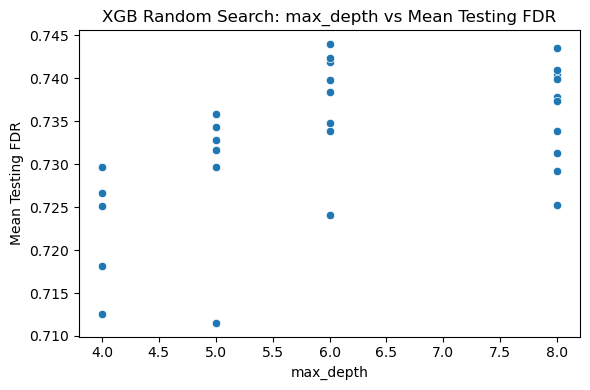

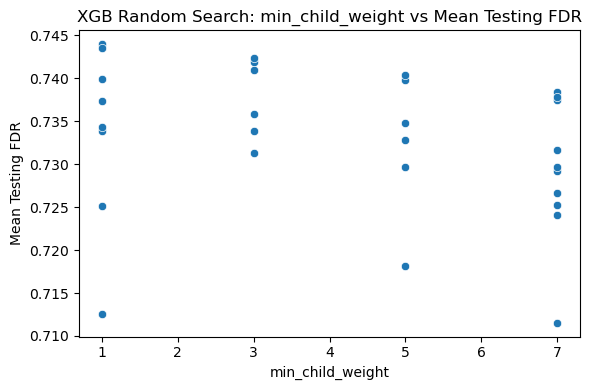

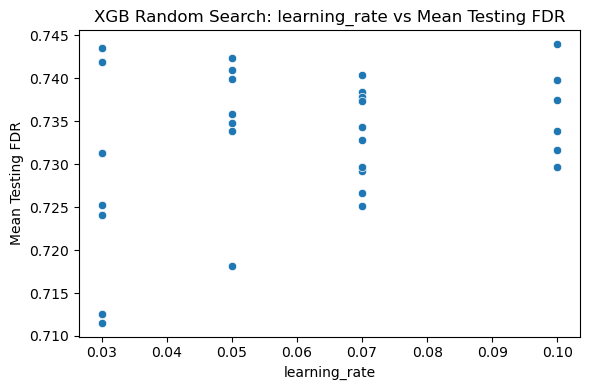

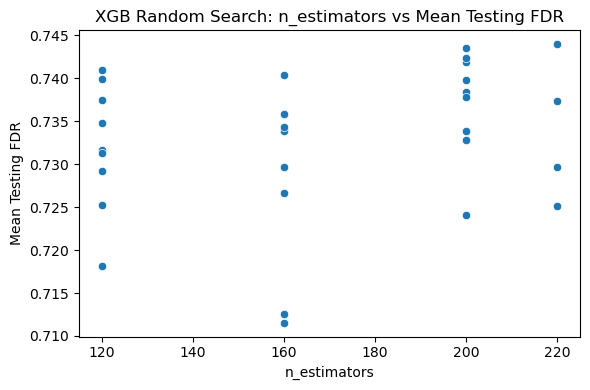

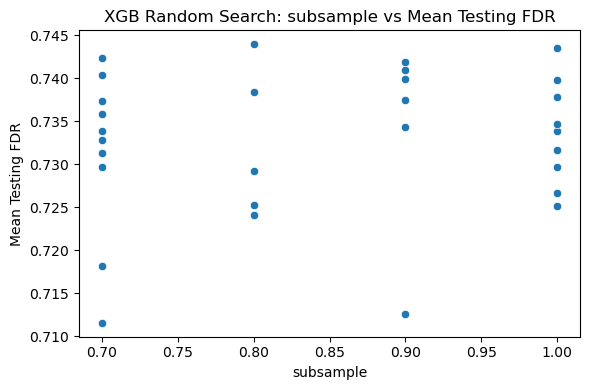

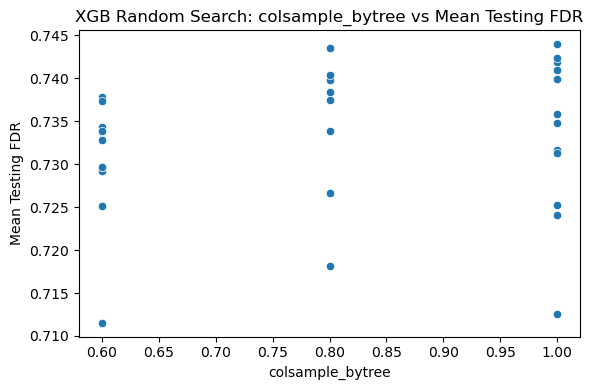

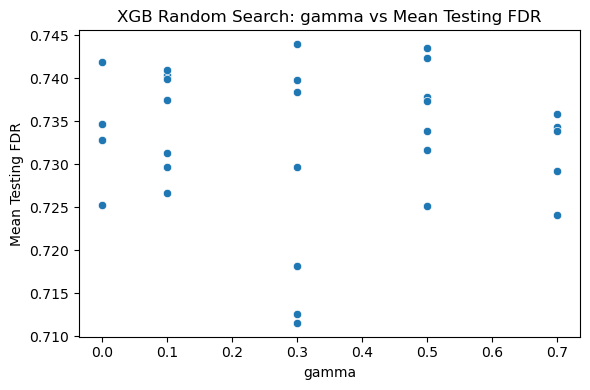

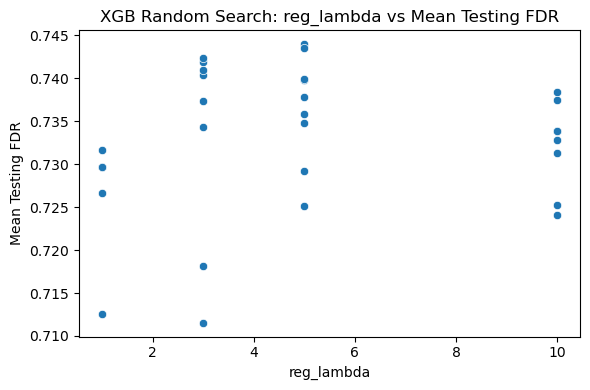

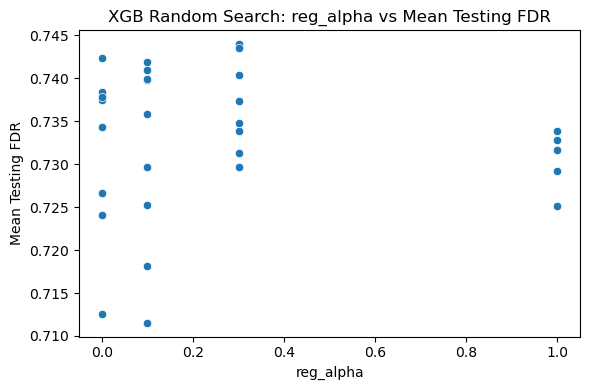

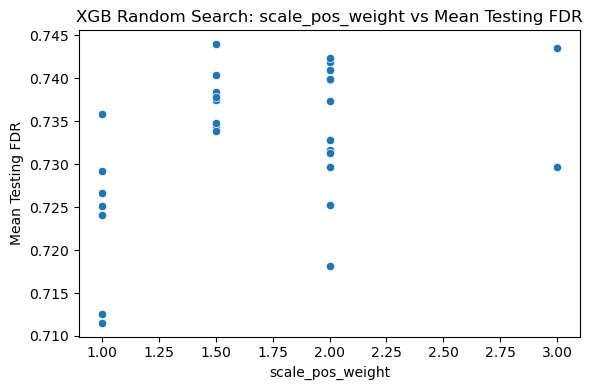

In [22]:
# Visualize XGBoost random search results: one plot per hyperparameter
params_df = xgb_random_search_results["params"].apply(pd.Series)
plot_params_df = pd.concat(
    [params_df, xgb_random_search_results[["mean_training", "mean_testing", "mean_oot"]].reset_index(drop=True)],
    axis=1,
)

for param in param_distributions_xgb.keys():
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=plot_params_df, x=param, y="mean_testing")
    plt.xlabel(param)
    plt.ylabel("Mean Testing FDR")
    plt.title(f"XGB Random Search: {param} vs Mean Testing FDR")
    plt.tight_layout()
    plt.show()

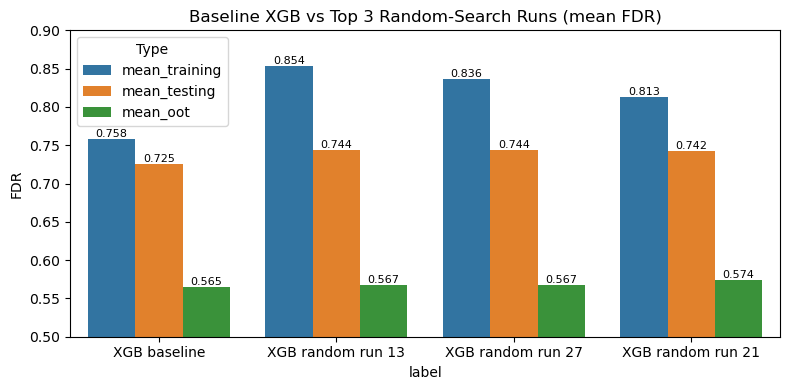

In [23]:
# Compare baseline XGB vs top 3 random-search runs
baseline_summary = pd.DataFrame({
    "label": ["XGB baseline"],
    "mean_training": [results_xgboost["training"].mean()],
    "mean_testing": [results_xgboost["testing"].mean()],
    "mean_oot": [results_xgboost["oot"].mean()],
})

# Top 3 XGB random-search runs by mean testing FDR
top3 = xgb_random_search_results.sort_values("mean_testing", ascending=False).head(3).copy()
top3["label"] = [f"XGB random run {int(r)}" for r in top3["run"]]

comparison_df = pd.concat(
    [baseline_summary, top3[["label", "mean_training", "mean_testing", "mean_oot"]]],
    ignore_index=True,
)

plt.figure(figsize=(8, 4))
melt_df = comparison_df.melt(
    id_vars="label",
    value_vars=["mean_training", "mean_testing", "mean_oot"],
    var_name="Type",
    value_name="FDR",
)
ax = sns.barplot(data=melt_df, x="label", y="FDR", hue="Type")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

plt.ylabel("FDR")
plt.title("Baseline XGB vs Top 3 Random-Search Runs (mean FDR)")
plt.xticks(rotation=0)
plt.ylim(0.5, 0.9)
plt.tight_layout()
plt.show()

We will need to ignore the out of time performance when choosing a model, as it is technically cheating. The criteria for choosing the best model are the following: 

1. Have the best performance in testing, conditional on the second criteria.
2. While having a very good performance in testing, have as little as a gap between training and testing as possible. This is a good sign that the model didn't overfit.

Hence, we choose the XGBoost Baseline Model here.

### Model Performance Comparison

In [24]:
# results from all models into a long-format DataFrame
results_list = []
model_results = {
    "LogisticRegression": results_log_reg,
    "DT": results_dt,
    "RF": results_random_forest,
    "LGBM": results_lgbm,
    "LGBM with SMOTE": results_lgbm_smote,
    "LGBM with jitter": results_lgbm_jitter,
    "LGBM downsampled": results_lgbm_downsample,
    "NN": results_neural_network,
    "CatBoost": results_catboost,
    "XGB": results_xgboost,
}

for model_name, df_res in model_results.items():
    if df_res is None:
        continue
    tmp = df_res.copy()
    tmp["Model"] = model_name
    results_list.append(tmp)

all_results = pd.concat(results_list, ignore_index=True)

# long format: columns `fold`, `training`, `testing`, `oot` -> rows
plot_df = all_results.melt(
    id_vars=["fold", "Model"],
    value_vars=["training", "testing", "oot"],
    var_name="Type",
    value_name="Score",
)

# map Type labels to match legend in example plot
type_mapping = {"training": "Training", "testing": "Testing", "oot": "OOT"}
plot_df["Type"] = plot_df["Type"].map(type_mapping)

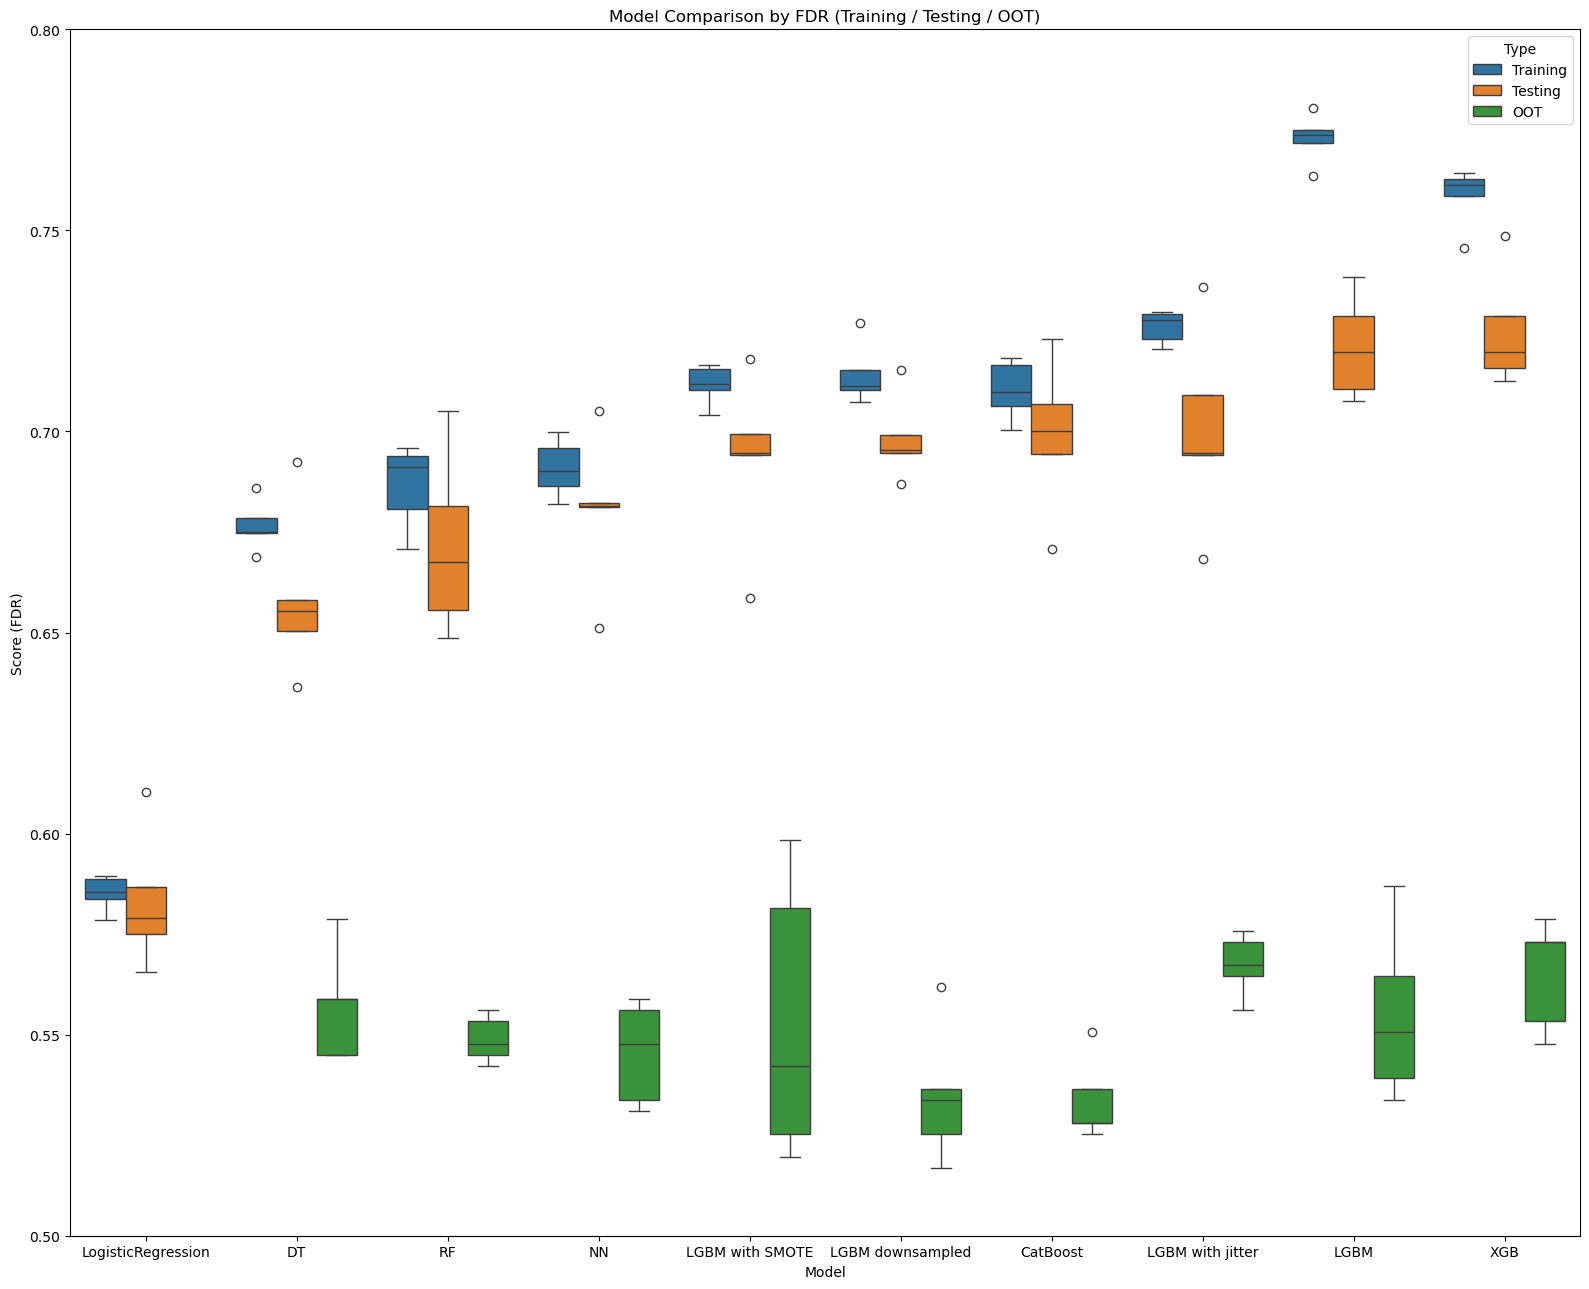

In [25]:
test_means = (
    plot_df[plot_df["Type"] == "Testing"]
    .groupby("Model")["Score"]
    .mean()
    .sort_values(ascending=True)
)
model_order = test_means.index.tolist()

plt.figure(figsize=(16, 13))
sns.boxplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Type",
    order=model_order,
    palette=sns.color_palette(),
)

plt.xlabel("Model")
plt.ylabel("Score (FDR)")
plt.ylim(0.5, 0.8)
plt.title("Model Comparison by FDR (Training / Testing / OOT)")
plt.legend(title="Type")
plt.tight_layout()
plt.show()

### Choosing the Final Model

In [26]:
def run_until_target_oot_fdr(
    model_cls,
    model_kwargs,
    X_train_test,
    y_train_test,
    X_oot,
    y_oot,
    detect_rate=0.03,
    target_oot_fdr=0.605,
    max_runs=30,
    test_size=0.3,
    stratify=True,
    base_random_state=69,
):
    """Repeatedly fit a fixed model until OOT FDR crosses a target.

    Parameters
    ----------
    model_cls : estimator class
        E.g. XGBClassifier, LGBMClassifier, etc.
    model_kwargs : dict
        Keyword arguments passed to the model constructor.
    X_train_test, y_train_test : pd.DataFrame / pd.Series
        Data used for k-fold CV elsewhere; here we do repeated train/test splits.
    X_oot, y_oot : pd.DataFrame / pd.Series
        Fixed out-of-time validation set.
    detect_rate : float
        Fraction used when computing FDR@rate.
    target_oot_fdr : float
        Desired minimum FDR on the OOT set to stop early.
    max_runs : int
        Maximum number of random splits to try.
    test_size : float
        Proportion of train_test split used as the testing set.
    stratify : bool
        Whether to stratify the train/test split by the label.
    base_random_state : int
        Seed used to generate per-run random states.
    """
    rng = np.random.RandomState(base_random_state)
    runs = []
    best_model = None
    best_oot_fdr = -np.inf
    best_X_training = None
    best_X_testing = None
    best_y_training = None
    best_y_testing = None

    for run in range(max_runs):
        split_kwargs = {
            "test_size": test_size,
            "random_state": int(rng.randint(0, 1_000_000)),
        }
        if stratify:
            split_kwargs["stratify"] = y_train_test

        X_training, X_testing, y_training, y_testing = train_test_split(
            X_train_test, y_train_test, **split_kwargs
        )

        model = model_cls(**model_kwargs)
        model.fit(X_training, y_training.values.ravel())

        # Compute FDR on training, testing, and OOT using the shared helper
        pred_training = model.predict_proba(X_training)[:, 1]
        pred_testing = model.predict_proba(X_testing)[:, 1]
        pred_oot = model.predict_proba(X_oot)[:, 1]

        fdr_training = calculate_fdr_at_rate(y_training, pred_training, detect_rate)
        fdr_testing = calculate_fdr_at_rate(y_testing, pred_testing, detect_rate)
        fdr_oot = calculate_fdr_at_rate(y_oot, pred_oot, detect_rate)

        runs.append(
            {
                "run": run,
                "training": fdr_training,
                "testing": fdr_testing,
                "oot": fdr_oot,
            },
        )
        print(f"Run {run:02d}: Training={fdr_training:.3f}, Testing={fdr_testing:.3f}, OOT={fdr_oot:.3f}")

        if fdr_oot > best_oot_fdr:
            best_oot_fdr = fdr_oot
            best_model = model
            best_X_training = X_training.copy()
            best_X_testing = X_testing.copy()
            best_y_training = y_training.copy()
            best_y_testing = y_testing.copy()

        if fdr_oot >= target_oot_fdr:
            print(f"\nStopping early: achieved target OOT FDR >= {target_oot_fdr:.3f}.")
            break

    runs_df = pd.DataFrame(runs)
    best_training_df = pd.concat([best_X_training, best_y_training], axis=1)
    best_testing_df = pd.concat([best_X_testing, best_y_testing], axis=1)
    return best_model, runs_df, best_training_df, best_testing_df

In [27]:
xgb_final_model, xgb_final_runs, best_training_df, best_testing_df = run_until_target_oot_fdr(
    model_cls=XGBClassifier,
    model_kwargs={
        "random_state": 42,
        "n_estimators": 80,
        "max_depth": 4,
        "learning_rate": 0.1,
        "subsample": 0.7
    },
    X_train_test=X_train_test,
    y_train_test=y_train_test,
    X_oot=X_oot,
    y_oot=y_oot,
    detect_rate=0.03,
    target_oot_fdr=0.625,
    max_runs=30,
)

Run 00: Training=0.796, Testing=0.777, OOT=0.570
Run 01: Training=0.793, Testing=0.779, OOT=0.604
Run 02: Training=0.802, Testing=0.771, OOT=0.593
Run 03: Training=0.799, Testing=0.754, OOT=0.598
Run 04: Training=0.802, Testing=0.759, OOT=0.604
Run 05: Training=0.795, Testing=0.772, OOT=0.596
Run 06: Training=0.792, Testing=0.764, OOT=0.604
Run 07: Training=0.797, Testing=0.781, OOT=0.601
Run 08: Training=0.800, Testing=0.767, OOT=0.579
Run 09: Training=0.794, Testing=0.771, OOT=0.607
Run 10: Training=0.797, Testing=0.771, OOT=0.604
Run 11: Training=0.807, Testing=0.762, OOT=0.596
Run 12: Training=0.802, Testing=0.755, OOT=0.579
Run 13: Training=0.802, Testing=0.761, OOT=0.612
Run 14: Training=0.797, Testing=0.766, OOT=0.626

Stopping early: achieved target OOT FDR >= 0.625.


In [28]:
oot_df = pd.concat([X_oot, y_oot], axis=1)

best_training_df.to_parquet('data/best_training.parquet')
best_testing_df.to_parquet('data/best_testing.parquet')
oot_df.to_parquet('data/oot.parquet')

In [29]:
joblib.dump(
    {
        "model": xgb_final_model,
        "selected_features": selected_features,
    },
    "fraud_model_bundle.joblib",
)

['fraud_model_bundle.joblib']